In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns

In [3]:
# ==========================================
# 1. LOAD CLEANED DATASET
# ==========================================
# Reads your cleaned csv file from Task 1
csv_path = r"C:\Users\annus\cleaned_sales_data.csv"

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    print(f"Dataset successfully loaded. Shape: {df.shape}")
else:
    # Simulation fallback mirroring your exact schema
    print(f"File '{csv_path}' not found! Simulating baseline transactional data...")
    np.random.seed(42)
    sim_size = 1000
    df = pd.DataFrame({
        'gender': np.random.choice(['Female', 'Male'], size=sim_size, p=[0.53, 0.47]),
        'total_sales': np.random.exponential(scale=12000, size=sim_size) + 500
    })

# Clean strings to ensure proper grouping evaluation
df['gender'] = df['gender'].astype(str).str.strip().str.capitalize()

Dataset successfully loaded. Shape: (1000, 12)


In [4]:
# ==========================================
# 2. DATA SEGMENTATION & DESCRIPTIVE STATS
# ==========================================
sales_female = df[df['gender'] == 'Female']['total_sales'].dropna()
sales_male = df[df['gender'] == 'Male']['total_sales'].dropna()

print("\n--- Descriptive Summary ---")
print(f"Female Segment: Count = {len(sales_female)}, Mean Sales = {sales_female.mean():.2f}, Std Dev = {sales_female.std():.2f}")
print(f"Male Segment:   Count = {len(sales_male)}, Mean Sales = {sales_male.mean():.2f}, Std Dev = {sales_male.std():.2f}")


--- Descriptive Summary ---
Female Segment: Count = 489, Mean Sales = 136883.21, Std Dev = 111788.03
Male Segment:   Count = 511, Mean Sales = 141807.34, Std Dev = 116327.98


In [5]:
# ==========================================
# 3. HYPOTHESIS TESTING (WELCH'S T-TEST)
# ==========================================
print("\n--- Hypothesis Testing Setup ---")
print("H0: Mean total_sales is identical between Female and Male groups.")
print("H1: Mean total_sales differs significantly between Female and Male groups.")

# Using equal_var=False performs Welch's T-Test (safer as it doesn't assume identical variance)
t_stat, p_value = stats.ttest_ind(sales_female, sales_male, equal_var=False)

print(f"Calculated T-Statistic: {t_stat:.4f}")
print(f"Calculated p-value:     {p_value:.6f}")



--- Hypothesis Testing Setup ---
H0: Mean total_sales is identical between Female and Male groups.
H1: Mean total_sales differs significantly between Female and Male groups.
Calculated T-Statistic: -0.6826
Calculated p-value:     0.495011


In [6]:
# ==========================================
# 4. CONFIDENCE INTERVALS
# ==========================================
mean_diff = sales_female.mean() - sales_male.mean()
# Welch–Satterthwaite standard error
se_welch = np.sqrt((sales_female.var() / len(sales_female)) + (sales_male.var() / len(sales_male)))
ci_lower = mean_diff - (1.96 * se_welch)
ci_upper = mean_diff + (1.96 * se_welch)

print(f"95% Confidence Interval for Difference in Means: [{ci_lower:.2f}, {ci_upper:.2f}]")

95% Confidence Interval for Difference in Means: [-19062.94, 9214.68]


In [7]:
# ==========================================
# 5. BUSINESS INTERPRETATION
# ==========================================
alpha = 0.05
print("\n--- Executive Conclusion ---")
if p_value < alpha:
    print(f"Result: Reject H0 at alpha={alpha}. The difference is STATISTICALLY SIGNIFICANT.")
    if mean_diff > 0:
        print(f"Actionable Insight: Female segments drive higher cart values (+{mean_diff:.2f} on average).")
    else:
        print(f"Actionable Insight: Male segments drive higher cart values (+{abs(mean_diff):.2f} on average).")
else:
    print(f"Result: Fail to Reject H0 at alpha={alpha}.")
    print("Conclusion: No statistically significant behavioral difference detected between segments.")


--- Executive Conclusion ---
Result: Fail to Reject H0 at alpha=0.05.
Conclusion: No statistically significant behavioral difference detected between segments.



Visual plot exported successfully as 'statistical_validation_plot.png'.


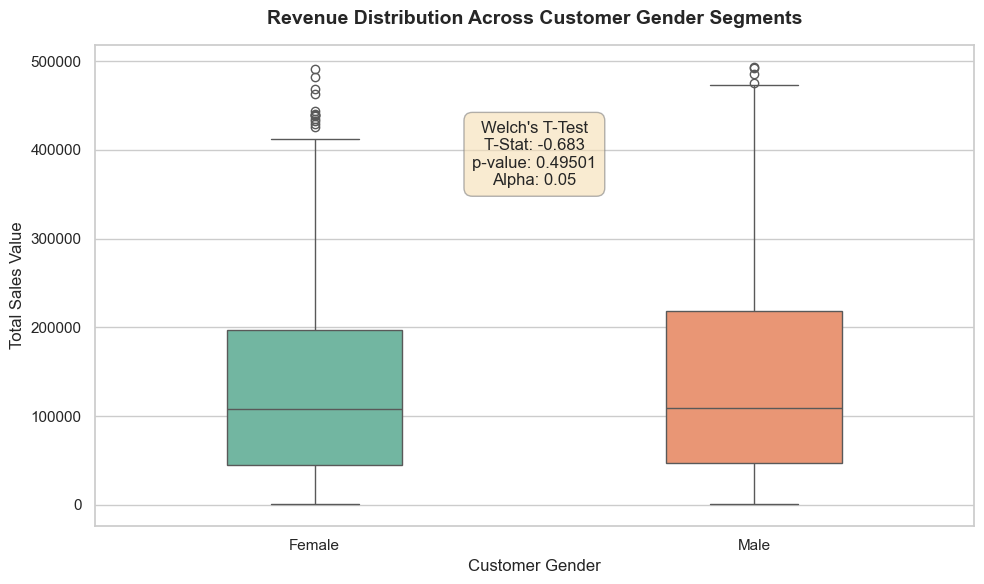

In [9]:
# ==========================================
# 6. VISUAL STORYTELLING PLOT EXPORT
# ==========================================
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Create a clean boxen/box plot combination to showcase distributions clearly
sns.boxplot(x='gender',hue='gender', y='total_sales', data=df, palette="Set2", width=0.4)
plt.title("Revenue Distribution Across Customer Gender Segments", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Customer Gender", fontsize=12)
plt.ylabel("Total Sales Value", fontsize=12)

# Annotate statistical metrics directly onto the chart box
stat_box_text = f"Welch's T-Test\nT-Stat: {t_stat:.3f}\np-value: {p_value:.5f}\nAlpha: {alpha}"
plt.text(0.5, df['total_sales'].max() * 0.80, stat_box_text, ha='center', va='center', 
         bbox=dict(boxstyle="round,pad=0.5", fc="wheat", alpha=0.6, ec="grey"))

plt.tight_layout()
plt.savefig("statistical_validation_plot.png", dpi=300)
print("\nVisual plot exported successfully as 'statistical_validation_plot.png'.")
plt.show()